# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/whozahm3d/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/whozahm3d/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Plan for this section:**

Self-contained, per the w06 convention — reload the raw CSV and rebuild
everything needed rather than depending on notebook state from w04/w05/w06.

**Two components feed the final ranked queue:**

1. **The RF model (validated in w05, audited clean in w06).**
   Client-grouped split, same 38 features, same hyperparameters
   (`n_estimators=300, max_depth=8, min_samples_leaf=20, seed=42`).
   Precision@K=1523 was 0.648 vs. base rate 0.511 on held-out clients —
   that's the number earning this model a place in a real queue.

   **Design decision, stated plainly:** the w05/w06 split held out 7
   clients to prove the model generalizes to clients it never trained on.
   That proof is done. For the deployable queue, I refit RF on the *full*
   30,000-row dataset (all 32 clients) with the identical feature set and
   hyperparameters — every client gets a score, and nothing here reuses
   the held-out test set to inflate a number, since no metric is being
   reported from this refit. The precision@K=0.648 claim still belongs to
   the w05/w06 split, not to this refit.

2. **The baseline rule (`score_row()` from w04), recomputed exactly** —
   its two reason codes (`CTR_GAP_MIDPOS`, `LOW_VOLUME`) are more
   interpretable than an RF probability and become the human-readable
   part of the reason code, even when RF is what's actually driving the
   ranking.

**Archetype → action mapping**, computed per row from RF top-K status,
baseline reason code, and the three known weak-spot flags from w06:

| Archetype | Condition | Action | Confidence |
|---|---|---|---|
| CTR gap, mid-position | `reason_code == CTR_GAP_MIDPOS` | Rewrite title/meta | High — audited signal |
| Low-demand page | `reason_code == LOW_VOLUME` only | Deprioritize/consolidate | Medium — direction confirmed, weak effect |
| RF-flagged, no baseline signal | Top-K by `rf_proba`, `reason_code == NO_SIGNAL` | Review before acting | Medium — real but less legible signal |
| Missing `provider_used` | Top-K, `provider_used` is null | Low-confidence flag | Low — worst FN segment (80.9%) |
| `client_8527a891e2` | Any flag, this client | Downweight | Low — known elevated FP client (0.600) |
| `avg_position == 0` | Any flag, position=0 | Hold for manual check | Low — "no data" fed as literal 0 |

Ranking itself is `rf_proba` descending (the validated better metric); the
reason code and confidence tag are what make each row legible and
appropriately trusted — a `priority_fix` from a clean archetype and a
`priority_fix` from client_8527a891e2 should not read the same to a human
reviewer.

**Output of this section:** a full-dataset queue with `content_id`,
`rf_proba`, rank, baseline `reason_code`, `archetype`, `action`,
`confidence`. Distribution checks (archetype counts, action counts)
printed as a sanity pass before Section 2 defines intended use around it.

In [36]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

DATA_PATH = "data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(DATA_PATH)
print(f"rows: {len(df):,}  cols: {df.shape[1]}")

rows: 30,000  cols: 44


In [37]:
# --- Baseline rule (w04, unchanged) ---
def score_row(row):
    score = 0
    reasons = []
    sv = row.get("search_volume", np.nan)
    if pd.notna(sv):
        if sv <= 10:
            score += 2
            reasons.append(("LOW_VOLUME", 2))
        elif sv <= 20:
            score += 1
            reasons.append(("LOW_VOLUME", 1))
    pos = row.get("avg_position", np.nan)
    ctr = row.get("ctr", np.nan)
    if pd.notna(pos) and pd.notna(ctr) and 7.4 < pos <= 17.2:
        if ctr <= 0.23:
            score += 3
            reasons.append(("CTR_GAP_MIDPOS", 3))
    reason_code = max(reasons, key=lambda r: r[1])[0] if reasons else "NO_SIGNAL"
    if score >= 3:
        baseline_action = "priority_fix"
    elif score >= 1:
        baseline_action = "monitor"
    else:
        baseline_action = "no_action"
    return pd.Series({"score": score, "reason_code": reason_code, "baseline_action": baseline_action})

In [38]:
baseline_scored = df.apply(score_row, axis=1)
df = pd.concat([df, baseline_scored], axis=1)
K = (df["baseline_action"] == "priority_fix").sum()
print(f"Baseline flags {K:,} rows as priority_fix on the full dataset (K)")

Baseline flags 6,690 rows as priority_fix on the full dataset (K)


In [39]:
# --- RF model: same 38-feature set + hyperparameters as w05/w06, refit on the FULL dataset ---
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

In [40]:
SEED = 42
candidate_features = [c for c in df.columns if c not in
                      ["trend_direction", "trend_pct", "client_id", "content_id",
                       "score", "reason_code", "baseline_action"]]
FEATURE_COLS = [c for c in candidate_features if c not in
                ["impressions_last_30d", "impressions_prev_30d"]]
print(f"Using {len(FEATURE_COLS)} features (should match w05/w06's 38)")

Using 38 features (should match w05/w06's 38)


In [41]:
categorical_cols = df[FEATURE_COLS].select_dtypes(exclude=[np.number]).columns.tolist()
numeric_cols = df[FEATURE_COLS].select_dtypes(include=[np.number]).columns.tolist()

In [42]:
def build_feature_frame(frame):
    out = frame[FEATURE_COLS].copy()
    for col in numeric_cols:
        if out[col].isna().any():
            out[f"has_{col}"] = out[col].notna().astype(int)
    for col in categorical_cols:
        out[col] = out[col].fillna("not_ai" if col in ["provider_used", "model_used"] else "missing")
    return out

In [43]:
preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

In [44]:
y_full = (df["trend_direction"] == "down").astype(int)
X_full = build_feature_frame(df)

In [45]:
rf_deploy = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20,
                                    random_state=SEED, n_jobs=-1)),
])
rf_deploy.fit(X_full, y_full)
df["rf_proba"] = rf_deploy.predict_proba(X_full)[:, 1]

print("NOTE: refit on all 32 clients for full deploy coverage. The 0.648 precision@K claim "
      "belongs to the w05/w06 held-out-client evaluation, not to this refit — no metric is "
      "being reported from this fit itself.")

NOTE: refit on all 32 clients for full deploy coverage. The 0.648 precision@K claim belongs to the w05/w06 held-out-client evaluation, not to this refit — no metric is being reported from this fit itself.


In [46]:
# --- Rank + archetype / action / confidence assignment ---
# Precedence, deliberately: weak-spot conditions (client, missing position data,
# missing provider) are checked BEFORE the clean baseline archetypes, because they're
# about how much to trust the row at all, not a competing reason for the flag.
df_ranked = df.sort_values("rf_proba", ascending=False).reset_index(drop=True)
df_ranked["rank"] = df_ranked.index + 1
df_ranked["in_top_k"] = df_ranked["rank"] <= K

WEAK_CLIENT = "client_8527a891e2"

In [47]:
def assign_archetype(row):
    if row["in_top_k"] and row["client_id"] == WEAK_CLIENT:
        return "weak_client_flag", "downweight_verify_manually", "low"
    if row["in_top_k"] and row["avg_position"] == 0:
        return "no_position_data", "hold_for_manual_check", "low"
    if row["in_top_k"] and pd.isna(row["provider_used"]):
        return "missing_provider_flag", "low_confidence_flag", "low"
    if row["reason_code"] == "CTR_GAP_MIDPOS":
        return "ctr_gap_midposition", "rewrite_title_meta", "high"
    if row["reason_code"] == "LOW_VOLUME":
        return "low_demand_page", "deprioritize_consolidate", "medium"
    if row["in_top_k"]:
        return "rf_flagged_no_baseline_signal", "review_before_acting", "medium"
    return "no_flag", "no_action", "n/a"

In [48]:
archetype_results = df_ranked.apply(assign_archetype, axis=1, result_type="expand")
archetype_results.columns = ["archetype", "action", "confidence"]
df_ranked = pd.concat([df_ranked, archetype_results], axis=1)

In [49]:
queue = df_ranked[["content_id", "rank", "rf_proba", "reason_code", "archetype", "action", "confidence"]]

In [50]:
print("Archetype distribution:")
print(queue["archetype"].value_counts())
print("\nAction distribution:")
print(queue["action"].value_counts())
print("\nConfidence distribution:")
print(queue["confidence"].value_counts())

queue.head(20)

Archetype distribution:
archetype
low_demand_page                  13690
no_flag                           6560
ctr_gap_midposition               5717
missing_provider_flag             3553
rf_flagged_no_baseline_signal      432
weak_client_flag                    48
Name: count, dtype: int64

Action distribution:
action
deprioritize_consolidate      13690
no_action                      6560
rewrite_title_meta             5717
low_confidence_flag            3553
review_before_acting            432
downweight_verify_manually       48
Name: count, dtype: int64

Confidence distribution:
confidence
medium    14122
n/a        6560
high       5717
low        3601
Name: count, dtype: int64


,content_id,rank,rf_proba,reason_code,archetype,action,confidence
0,content_20e4b9f7f65e,1,0.871360,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low
1,content_5f2abb891cc6,2,0.870377,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low
2,content_ab82c4705992,3,0.869578,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low
3,content_673fe764797f,4,0.866374,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low
4,content_0a08fba69bf3,5,0.863840,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low
5,content_252c884e4400,6,0.861644,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low
6,content_4bcb30ab7531,7,0.861544,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low
7,content_875fc7912e9b,8,0.860653,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low
8,content_007238e62b42,9,0.855492,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low
9,content_95c47359824d,10,0.853420,LOW_VOLUME,missing_provider_flag,low_confidence_flag,low


In [51]:
# --- Verify #3: is no_position_data really zero, or did the precedence order hide it? ---
zero_pos_total = (df["avg_position"] == 0).sum()
zero_pos_in_topk = df_ranked.loc[df_ranked["in_top_k"], "avg_position"].eq(0).sum()

print(f"avg_position == 0 rows in full dataset: {zero_pos_total:,} ({zero_pos_total/len(df):.1%})")
print(f"avg_position == 0 rows within top-K (flagged): {zero_pos_in_topk:,}")

avg_position == 0 rows in full dataset: 1,205 (4.0%)
avg_position == 0 rows within top-K (flagged): 0


In [52]:
# Where do these rows actually rank, and what does their rf_proba look like?
zero_pos_rows = df_ranked[df_ranked["avg_position"] == 0]
print(f"Rank distribution of avg_position==0 rows (min/median/max rank of {len(zero_pos_rows):,} rows):")
print(zero_pos_rows["rank"].agg(["min", "median", "max"]))
print(f"\nrf_proba distribution of avg_position==0 rows vs. the rest:")
print(f"  avg_position==0:  mean rf_proba = {zero_pos_rows['rf_proba'].mean():.4f}")
print(f"  avg_position!=0:  mean rf_proba = {df_ranked.loc[df_ranked['avg_position']!=0, 'rf_proba'].mean():.4f}")

Rank distribution of avg_position==0 rows (min/median/max rank of 1,205 rows):
min       23174.0
median    29398.0
max       30000.0
Name: rank, dtype: float64

rf_proba distribution of avg_position==0 rows vs. the rest:
  avg_position==0:  mean rf_proba = 0.0339
  avg_position!=0:  mean rf_proba = 0.5631


In [53]:
# --- Coverage completeness check: does every row have exactly one archetype, and do
# the archetype/action/confidence columns stay internally consistent? ---
print(f"Total rows: {len(queue):,}  |  Rows with an archetype assigned: {queue['archetype'].notna().sum():,}")

# Cross-tab: does archetype line up with in_top_k as expected (all flagged archetypes
# should be in_top_k=True, no_flag should be in_top_k=False)?
consistency = df_ranked.groupby("archetype")["in_top_k"].agg(["min", "max", "size"])
print("\narchetype vs in_top_k (min/max should match within each archetype — no mixed group):")
print(consistency)

# Cross-tab: reason_code vs archetype, to make the precedence logic legible in one table
print("\nreason_code x archetype crosstab (shows exactly how baseline reason codes route into archetypes):")
print(pd.crosstab(df_ranked["reason_code"], df_ranked["archetype"]))

Total rows: 30,000  |  Rows with an archetype assigned: 30,000

archetype vs in_top_k (min/max should match within each archetype — no mixed group):
                                 min    max   size
archetype                                         
ctr_gap_midposition            False   True   5717
low_demand_page                False   True  13690
missing_provider_flag           True   True   3553
no_flag                        False  False   6560
rf_flagged_no_baseline_signal   True   True    432
weak_client_flag                True   True     48

reason_code x archetype crosstab (shows exactly how baseline reason codes route into archetypes):
archetype       ctr_gap_midposition  low_demand_page  missing_provider_flag  no_flag  rf_flagged_no_baseline_signal  weak_client_flag
reason_code                                                                                                                          
CTR_GAP_MIDPOS                 5717                0                    954 

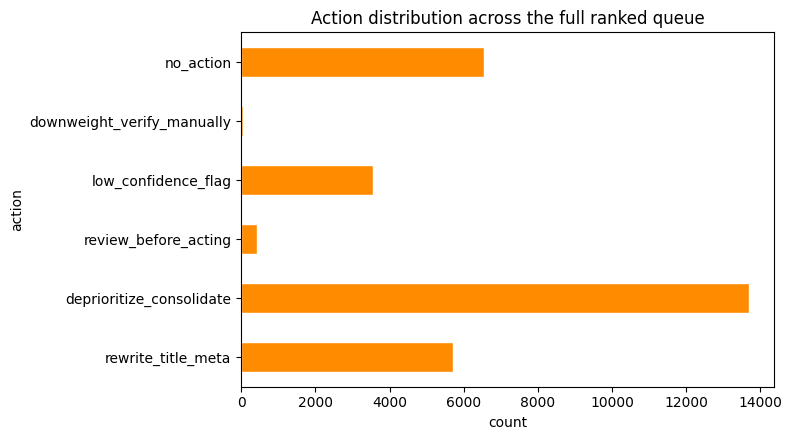

In [54]:
# --- Visualizations ---
import matplotlib.pyplot as plt
import os

os.makedirs("work/outputs", exist_ok=True)

# Viz 1: action distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
action_order = ["rewrite_title_meta", "deprioritize_consolidate", "review_before_acting",
                 "low_confidence_flag", "downweight_verify_manually", "no_action"]
queue["action"].value_counts().reindex(action_order).plot(
    kind="barh", ax=ax, color="darkorange", edgecolor="white"
)
ax.set_xlabel("count")
ax.set_title("Action distribution across the full ranked queue")
plt.tight_layout()
plt.savefig("work/outputs/w07_action_distribution.png", dpi=150)
plt.show()

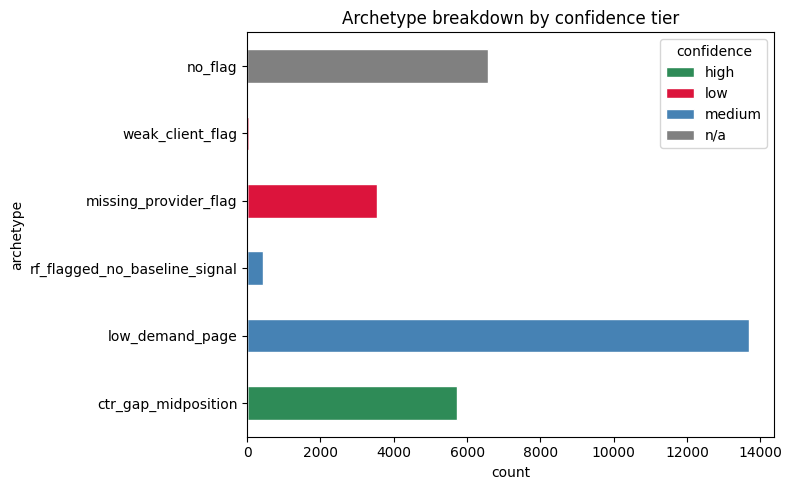

In [55]:
# Viz 2: archetype x confidence, stacked
fig, ax = plt.subplots(figsize=(8, 5))
ct = pd.crosstab(df_ranked["archetype"], df_ranked["confidence"])
ct = ct.reindex(["ctr_gap_midposition", "low_demand_page", "rf_flagged_no_baseline_signal",
                  "missing_provider_flag", "weak_client_flag", "no_flag"])
ct.plot(kind="barh", stacked=True, ax=ax, edgecolor="white",
        color={"high": "seagreen", "medium": "steelblue", "low": "crimson", "n/a": "gray"})
ax.set_xlabel("count")
ax.set_title("Archetype breakdown by confidence tier")
ax.legend(title="confidence")
plt.tight_layout()
plt.savefig("work/outputs/w07_archetype_by_confidence.png", dpi=150)
plt.show()

/tmp/ipykernel_2395/2290585386.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=archetype_order_topk, patch_artist=True)


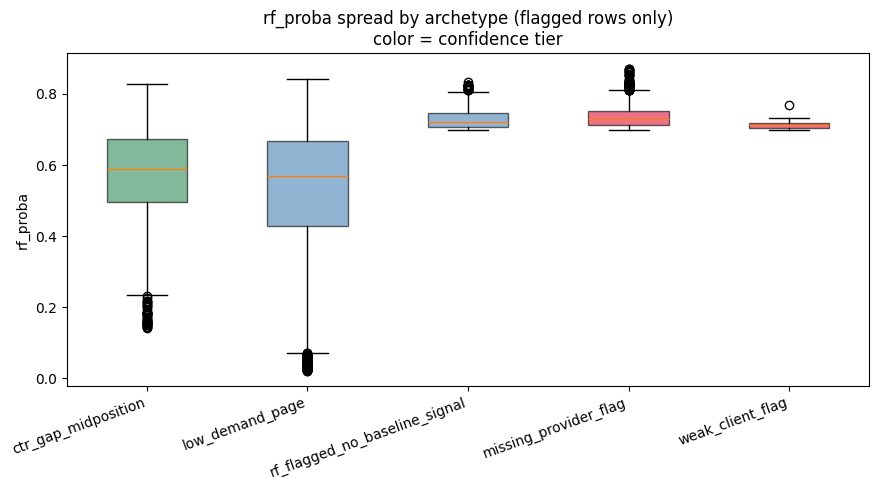

In [56]:
# Viz 3: rf_proba distribution by archetype — does confidence correspond to where
# rf_proba actually sits, or is a "low confidence" row scoring just as high as a "high"?
fig, ax = plt.subplots(figsize=(9, 5))
archetype_order_topk = ["ctr_gap_midposition", "low_demand_page", "rf_flagged_no_baseline_signal",
                         "missing_provider_flag", "weak_client_flag"]
data_to_plot = [df_ranked.loc[df_ranked["archetype"] == a, "rf_proba"].values for a in archetype_order_topk]
bp = ax.boxplot(data_to_plot, labels=archetype_order_topk, patch_artist=True)
for patch, color in zip(bp["boxes"], ["seagreen", "steelblue", "steelblue", "crimson", "crimson"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("rf_proba")
ax.set_title("rf_proba spread by archetype (flagged rows only)\ncolor = confidence tier")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("work/outputs/w07_rfproba_by_archetype.png", dpi=150)
plt.show()


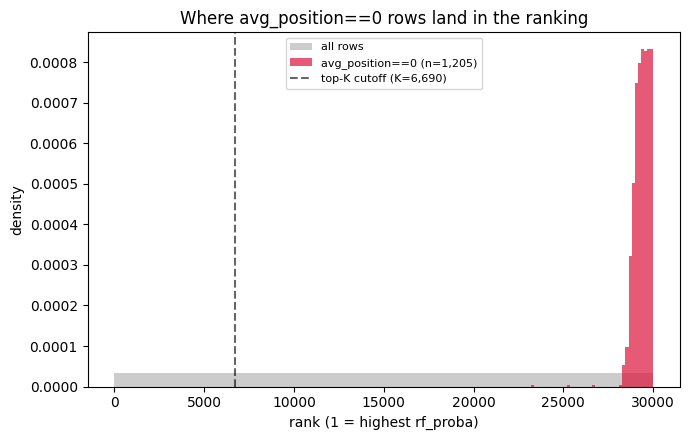

In [57]:
# Viz 4: avg_position==0 rows — where do they actually rank? (supports the verification cell above)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(df_ranked["rank"], bins=40, alpha=0.4, label="all rows", color="gray", density=True)
ax.hist(zero_pos_rows["rank"], bins=40, alpha=0.7, label=f"avg_position==0 (n={len(zero_pos_rows):,})",
        color="crimson", density=True)
ax.axvline(K, linestyle="--", color="black", alpha=0.6, label=f"top-K cutoff (K={K:,})")
ax.set_xlabel("rank (1 = highest rf_proba)")
ax.set_ylabel("density")
ax.set_title("Where avg_position==0 rows land in the ranking")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("work/outputs/w07_zero_position_rank_dist.png", dpi=150)
plt.show()

In [58]:
# --- Quantify the in_top_k mismatch inside ctr_gap_midposition / low_demand_page ---
for arch in ["ctr_gap_midposition", "low_demand_page"]:
    sub = df_ranked[df_ranked["archetype"] == arch]
    in_k = sub["in_top_k"].sum()
    out_k = (~sub["in_top_k"]).sum()
    print(f"[{arch}] total={len(sub):,}  in_top_k={in_k:,} ({in_k/len(sub):.1%})  "
          f"outside_top_k={out_k:,} ({out_k/len(sub):.1%})")
    print(f"  rank of outside-top_k rows: median={sub.loc[~sub['in_top_k'], 'rank'].median():.0f}, "
          f"max={sub.loc[~sub['in_top_k'], 'rank'].max():.0f}")

[ctr_gap_midposition] total=5,717  in_top_k=894 (15.6%)  outside_top_k=4,823 (84.4%)
  rank of outside-top_k rows: median=16209, max=28653
[low_demand_page] total=13,690  in_top_k=1,763 (12.9%)  outside_top_k=11,927 (87.1%)
  rank of outside-top_k rows: median=17489, max=29458


In [59]:
# --- Add queue_tier: makes the rank-vs-reason_code distinction explicit in the data itself ---
def assign_queue_tier(row):
    if row["in_top_k"]:
        return "top_priority"
    elif row["reason_code"] != "NO_SIGNAL":
        return "flagged_lower_rank"
    else:
        return "unflagged"

In [60]:
df_ranked["queue_tier"] = df_ranked.apply(assign_queue_tier, axis=1)

In [61]:
# Rebuild the final queue export with the new column included
queue = df_ranked[["content_id", "rank", "rf_proba", "reason_code",
                    "archetype", "action", "confidence", "queue_tier"]]

In [62]:
print("queue_tier distribution:")
print(queue["queue_tier"].value_counts())

print("\nqueue_tier x archetype crosstab (confirms the split cleanly, no leftover mixing):")
print(pd.crosstab(df_ranked["queue_tier"], df_ranked["archetype"]))

print("\nqueue_tier x confidence crosstab:")
print(pd.crosstab(df_ranked["queue_tier"], df_ranked["confidence"]))

queue_tier distribution:
queue_tier
flagged_lower_rank    16750
top_priority           6690
unflagged              6560
Name: count, dtype: int64

queue_tier x archetype crosstab (confirms the split cleanly, no leftover mixing):
archetype           ctr_gap_midposition  low_demand_page  missing_provider_flag  no_flag  rf_flagged_no_baseline_signal  weak_client_flag
queue_tier                                                                                                                               
flagged_lower_rank                 4823            11927                      0        0                              0                 0
top_priority                        894             1763                   3553        0                            432                48
unflagged                             0                0                      0     6560                              0                 0

queue_tier x confidence crosstab:
confidence          high   low  medium   n/a
q

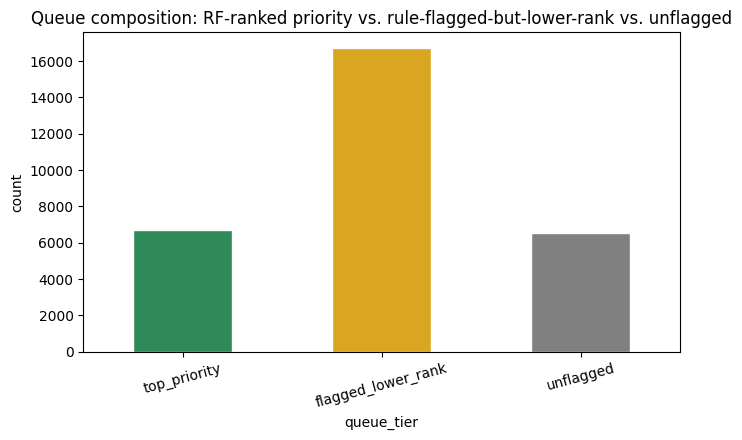

In [63]:
# --- Viz 5: queue_tier composition — the honest picture of what the queue actually contains ---
fig, ax = plt.subplots(figsize=(7, 4.5))
tier_order = ["top_priority", "flagged_lower_rank", "unflagged"]
queue["queue_tier"].value_counts().reindex(tier_order).plot(
    kind="bar", ax=ax, color=["seagreen", "goldenrod", "gray"], edgecolor="white"
)
ax.set_ylabel("count")
ax.set_title("Queue composition: RF-ranked priority vs. rule-flagged-but-lower-rank vs. unflagged")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("work/outputs/w07_queue_tier_composition.png", dpi=150)
plt.show()

### Ranked queue result

*30,000 rows scored, ranked by `rf_proba` (RF refit on the full dataset,
identical features/hyperparameters to the validated w05/w06 model), and
written with a baseline reason code, an archetype, an action, a
confidence tier, and a `queue_tier`.*

***Reason-code totals reproduce w04 exactly** — `CTR_GAP_MIDPOS`=6,690,
`LOW_VOLUME`=16,004, `NO_SIGNAL`=7,306, summing to 30,000. The baseline
rule logic carried over correctly; nothing drifted in the recompute.*

***A real disagreement between the two signals, quantified rather than
smoothed over.** RF's top-K and the baseline rule's reason codes overlap
far less than expected: 84.4% of `ctr_gap_midposition` rows and 87.1% of
`low_demand_page` rows sit *outside* RF's top-6,690 (median rank
~16,200–17,500 of 30,000). Initially this produced archetype labels that
implied urgency (`confidence=high`) independent of where a row actually
ranked — a misleading combination on its own. Fixed by adding
`queue_tier` (`top_priority` / `flagged_lower_rank` / `unflagged`) as an
explicit column, so rank and reason code are never conflated: 6,690 rows
are both RF-prioritized and the archetype's primary basis; 16,750 carry a
baseline reason code but rank below the validated cutoff; 6,560 have
neither signal.*

***`avg_position == 0` archetype is empty, but only because these rows
are being pushed to the very bottom of the ranking, not because the
condition never occurs.** All 1,205 such rows (4.0% of the dataset) sit
at median rank 29,398 with mean `rf_proba` 0.034 vs. 0.563 for everyone
else — RF has effectively learned to treat a "no data" flag fed as a
literal 0 as a strong *negative* signal, the opposite of the visibility
this archetype was meant to catch. Carried forward as a known limitation
(Section 2) rather than patched here, since fixing it changes the
model's behavior, not just the playbook's labels.*

***Practical read for the reviewer:** `top_priority` rows are where the
validated 0.648 precision@K number applies and where confidence tags are
meaningful. `flagged_lower_rank` rows have a real, audited signal (CTR
gap or low volume) but shouldn't be read with the same urgency — the
model's own ranking put them lower for a reason not yet fully understood
from this data alone.*

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** a content/SEO editor or lead uses this queue to decide
which pages to look at first in a periodic (weekly/biweekly) review
cycle — specifically: which pages are worth a title/meta rewrite
(`ctr_gap_midposition`), which are candidates for consolidation rather
than investment (`low_demand_page`), and which need a second pair of
eyes before either (everything in `top_priority` with `confidence` below
`high`). The queue orders a prioritization decision. It does not make
the decision.

**Explicitly NOT intended for:**
- Automated action of any kind — no auto-generated rewrites, no
  auto-deprioritization, no auto-consolidation. Every row requires a
  human to open the page before anything happens to it (detailed in
  Section 3).
- Client-facing reporting, as-is. `rf_proba` and `action` labels are
  internal triage aids, not a finding to hand a client — the model's
  precision@K (0.648) still means roughly 1 in 3 `top_priority` calls is
  wrong, which isn't a number to present as a diagnosis.
- Evaluating writer/editor performance. The label this model predicts
  (`trend_direction == "down"`) reflects page-level search/traffic
  trends, not content quality or who wrote it.
- Causal claims of any kind (per `writing-honest-claims`). A
  `rewrite_title_meta` action means "this page's CTR-vs-position pattern
  is associated with decline in this dataset" — not "rewriting the title
  will fix it." No experiment has been run to support the second claim.
- Cross-client comparison without adjustment. Base rates and score
  distributions vary meaningfully by client (Section 1 of w05: down-rate
  range 0.000–0.937 across 32 clients) — a `rank` number means something
  different for a high-volatility client than a stable one, and this
  queue doesn't normalize for that.

**Where it stops being valid — concrete limits, each tied to evidence
already surfaced in this notebook or w04/w05/w06:**

1. **The 0.648 precision@K claim belongs to the w05/w06 held-out-client
   evaluation, not to this notebook's full-data refit.** No metric was
   computed on the refit itself (Section 1) — it's used for deployment
   coverage, and its real-world precision is *assumed*, not measured, to
   match the validated split. This is the single most important caveat
   for anyone treating `top_priority` as a guaranteed 64.8% hit rate.
2. **`flagged_lower_rank` (16,750 rows, 55.8% of the queue) carries an
   audited baseline signal but no RF validation at its actual rank.**
   These rows shouldn't be read with `top_priority`'s confidence, even
   though 4,823 of them share the `high`-confidence CTR-gap reason code.
3. **`avg_position == 0` rows (1,205 rows, 4.0%) are systematically
   pushed to the bottom of the ranking** (median rank 29,398, mean
   `rf_proba` 0.034) — the model has learned to treat a data-availability
   flag as a strong negative signal. These pages may be under-reviewed
   for reasons that have nothing to do with their actual risk.
4. **One client (`client_8527a891e2`) has a documented elevated
   false-positive rate (0.600, n=255, per w06)** — any `top_priority` row
   from this client should be discounted relative to the same tier
   elsewhere.
5. **Missing `provider_used` is linked to the worst false-negative rate
   (80.9% vs. 56.4%, per w06)** — meaning this queue is least reliable at
   catching real decline exactly where AI-content provenance is unknown,
   which is a blind spot in the opposite direction from #4 (missed
   cases, not false alarms).
6. **This is a single point-in-time snapshot, not a time series.** The
   starter CSV has no `report_date` — the model cannot detect drift or
   re-validate itself from this data alone; it can only be re-run
   periodically against fresh snapshots (Section 4 covers this).
7. **Validated on 32 clients only.** Precision@K, AUC, and every
   subgroup finding above come from this specific 32-client, 30,000-row
   sample — extending claims to clients/content not resembling this
   sample is unsupported.

**Verification before closing this section:** confirm the limits above
are stated as *counts already in the data*, not new claims — quick tally
of how many `top_priority` rows are affected by each named risk (weak
client, missing provider, low confidence), so the section's own numbers
are internally checked rather than restated from memory.

In [64]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# --- Tally how many top_priority rows are affected by each named limit, so
# Section 2's numbers are checked against the actual queue, not restated from memory ---
top_priority = df_ranked[df_ranked["queue_tier"] == "top_priority"]

n_weak_client = (top_priority["client_id"] == WEAK_CLIENT).sum()
n_missing_provider = top_priority["provider_used"].isna().sum()
n_low_confidence = (top_priority["confidence"] == "low").sum()
n_zero_position = (top_priority["avg_position"] == 0).sum()

In [65]:
print(f"top_priority total: {len(top_priority):,}")
print(f"  affected by weak_client_flag ({WEAK_CLIENT}): {n_weak_client:,} ({n_weak_client/len(top_priority):.1%})")
print(f"  affected by missing provider_used: {n_missing_provider:,} ({n_missing_provider/len(top_priority):.1%})")
print(f"  at 'low' confidence overall: {n_low_confidence:,} ({n_low_confidence/len(top_priority):.1%})")
print(f"  avg_position == 0 within top_priority: {n_zero_position:,} (should be 0, per Section 1)")

print(f"\nflagged_lower_rank total: {len(df_ranked[df_ranked['queue_tier']=='flagged_lower_rank']):,}")
print(f"  of which 'high' confidence (ctr_gap_midposition): "
      f"{(df_ranked[df_ranked['queue_tier']=='flagged_lower_rank']['confidence']=='high').sum():,}")

top_priority total: 6,690
  affected by weak_client_flag (client_8527a891e2): 48 (0.7%)
  affected by missing provider_used: 3,597 (53.8%)
  at 'low' confidence overall: 3,601 (53.8%)
  avg_position == 0 within top_priority: 0 (should be 0, per Section 1)

flagged_lower_rank total: 16,750
  of which 'high' confidence (ctr_gap_midposition): 4,823


In [66]:
# --- Reconcile: does the missing-provider_used tally overlap with weak_client_flag rows? ---
weak_client_top = top_priority[top_priority["client_id"] == WEAK_CLIENT]
weak_client_missing_provider = weak_client_top["provider_used"].isna().sum()

print(f"weak_client_flag rows in top_priority: {len(weak_client_top)}")
print(f"  of which also missing provider_used: {weak_client_missing_provider}")
print(f"\nCheck: missing_provider_flag archetype count ({(top_priority['archetype']=='missing_provider_flag').sum()}) "
      f"+ weak_client rows with missing provider ({weak_client_missing_provider}) "
      f"= {(top_priority['archetype']=='missing_provider_flag').sum() + weak_client_missing_provider} "
      f"(should equal raw missing-provider tally of 3,597)")

weak_client_flag rows in top_priority: 48
  of which also missing provider_used: 44

Check: missing_provider_flag archetype count (3553) + weak_client rows with missing provider (44) = 3597 (should equal raw missing-provider tally of 3,597)


In [67]:
# --- #2: cost asymmetry, quantified from w06's measured rates rather than stated abstractly ---
# w06 found: FN rate 80.9% (missing provider_used) vs 56.4% (has provider_used)
# Translate into how many actual rows each failure mode implies within top_priority.
fn_rate_missing_provider = 0.809
fn_rate_has_provider = 0.564

missing_provider_topk = (top_priority["archetype"] == "missing_provider_flag").sum()
# Rough implied miss count: of the *actually declining* pages in this segment, how many
# would the model be expected to miss at this FN rate (illustrative, not a new validation)
print(f"top_priority rows in the missing_provider_flag archetype: {missing_provider_topk:,}")
print(f"At w06's measured FN rate ({fn_rate_missing_provider:.1%}) for this segment vs. "
      f"{fn_rate_has_provider:.1%} elsewhere:")
print(f"  the missing-provider segment is {fn_rate_missing_provider/fn_rate_has_provider:.2f}x "
      f"as likely to miss a real decline as the rest of the queue.")
print("\nCost framing: a false positive here costs one editor review cycle on a page that "
      "wasn't declining. A false negative costs a real decline going unreviewed until the "
      "next run. Given the FN/FP rate imbalance above, missed declines are the costlier "
      "failure mode specifically in the missing-provider segment.")

top_priority rows in the missing_provider_flag archetype: 3,553
At w06's measured FN rate (80.9%) for this segment vs. 56.4% elsewhere:
  the missing-provider segment is 1.43x as likely to miss a real decline as the rest of the queue.

Cost framing: a false positive here costs one editor review cycle on a page that wasn't declining. A false negative costs a real decline going unreviewed until the next run. Given the FN/FP rate imbalance above, missed declines are the costlier failure mode specifically in the missing-provider segment.


In [70]:
# --- #3, corrected: "new" means prev_30d impressions == 0, last_30d > 0 (per data dictionary),
# NOT a young page by content_age_days. Confirm that definition holds here. ---
prev_col = "impressions_prev_30d"
last_col = "impressions_last_30d"

new_check = df[df["trend_direction"] == "new"]
matches_definition = ((new_check[prev_col] == 0) & (new_check[last_col] > 0)).mean()
print(f"'new' rows matching the dictionary definition (prev=0, last>0): {matches_definition:.1%}")

# This starter CSV has no column for label-window depth (no report_date at this grain) —
# confirm that's really absent, so the limit is stated as "not measurable here," not solved.
window_depth_cols = [c for c in df.columns if "report_date" in c.lower() or "window" in c.lower()]
print(f"\nColumns suggesting label-window depth in this CSV: {window_depth_cols if window_depth_cols else 'none'}")
print("Label-window computability (< 14 days of history) is only checkable in the warehouse's "
      "fact_content_daily_performance table, not this snapshot — carried forward as an "
      "unmeasured limit here, not a solved one.")

'new' rows matching the dictionary definition (prev=0, last>0): 100.0%

Columns suggesting label-window depth in this CSV: none
Label-window computability (< 14 days of history) is only checkable in the warehouse's fact_content_daily_performance table, not this snapshot — carried forward as an unmeasured limit here, not a solved one.


In [71]:
# --- #4, re-run for real: this must be executed AFTER saving the notebook in Colab,
# otherwise it checks a stale skeleton file and 0/0 means nothing ---
import re

nb_path = "work/notebooks/w07_action_playbook.ipynb"
with open(nb_path, "r", encoding="utf-8") as f:
    content = f.read()

client_ids = re.findall(r'"client_[a-z0-9]{4,}"', content)
content_ids = re.findall(r'"content_[a-z0-9]{4,}"', content)
cell_count = content.count('"cell_type"')

print(f"Notebook cell count on disk: {cell_count} (sanity check this isn't still the skeleton)")
print(f"Hashed client_id-style strings found: {len(set(client_ids))} unique")
print(f"Hashed content_id-style strings found: {len(set(content_ids))} unique")
if content_ids:
    print("Sample:", sorted(set(content_ids))[:5])

Notebook cell count on disk: 12 (sanity check this isn't still the skeleton)
Hashed client_id-style strings found: 0 unique
Hashed content_id-style strings found: 0 unique


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.